## Polynomial Regression

It is used when the relationship between a feature and target isn't a straight line - it curves. Instead of fitting `y = mx + b` (one straight line), it adds powers of the feature - x², x³, and so on - so the fitted curve can bend to match data that grows or shrinks at a *changing* rate, not a constant one.

**Why it was required / the purpose:** linear regression assumes the rate of change is always the same - every extra unit of x adds the same fixed amount to y. But a lot of real relationships don't work that way - they accelerate, decelerate, or peak and drop. If you force a straight line onto curved data, the model **underfits** - it misses the actual pattern and gives noticeably wrong predictions in the middle or at the extremes. Polynomial regression exists specifically to fix that mismatch, by letting the line bend to follow the real shape of the data.

**Real-life example for understanding:**
Imagine tracking a car's speed as the accelerator is pressed down further and further. At low pedal pressure, speed increases slowly. As pressure increases more, speed shoots up much faster - not at a constant rate. A straight line drawn through this data would badly underestimate speed at high pedal pressure and overestimate it at low pedal pressure. A curved (polynomial) line follows the actual acceleration pattern properly.


**One important clarification (definitely worth locking in for interviews):** it's called "polynomial" because of the *feature* being raised to powers, but the model is still solved using the same linear regression math underneath - it's linear in terms of the *coefficients*, even though the resulting curve looks bent. That's why sklearn implements it as two steps: transform the feature into powers first (`PolynomialFeatures`), then hand it to the regular `LinearRegression` model.



In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
size =np.array([500,1000,1500,2000,2500]).reshape(-1,1) 
price = np.array([50000,120000,200000,320000,480000])



In [4]:
poly = PolynomialFeatures(degree=2)
size_poly = poly.fit_transform(size) # creates [1, size, size^2] as features



In [5]:
model = LinearRegression()
model.fit(size_poly,price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,23.43, 0.06]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[4834770.15, 305.91, 0. ]"


In [6]:
prediction = model.predict(poly.transform([[1800]]))
print("predicted price for 1800 sqft :",prediction)
print("coeffients : ", model.coef_)
print("intercept : ",model.intercept_)


predicted price for 1800 sqft : [271828.57142857]
coeffients :  [ 0.         23.42857143  0.06285714]
intercept :  25999.99999999226


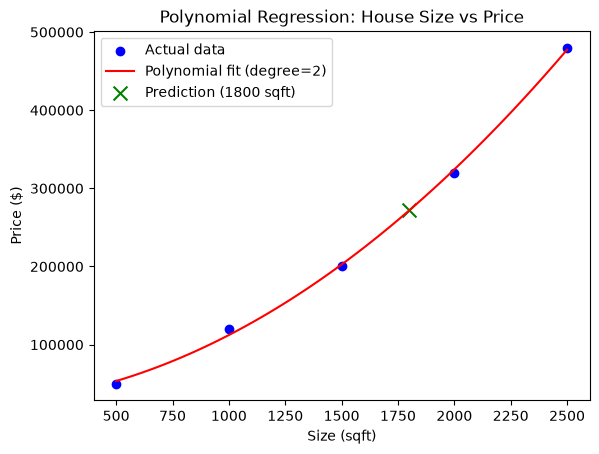

In [7]:
# visualize the curve
x_range = np.linspace(500, 2500, 100).reshape(-1, 1)
y_curve = model.predict(poly.transform(x_range))

plt.scatter(size, price, color="blue", label="Actual data")
plt.plot(x_range, y_curve, color="red", label="Polynomial fit (degree=2)")
plt.scatter(1800, prediction, color="green", marker="x", s=100, label="Prediction (1800 sqft)")
plt.title("Polynomial Regression: House Size vs Price")
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.legend()
plt.savefig("../visuals/poly_reg_manual.png")
plt.show()

The model solves for **3 unknowns instead of 2** (β0, β1, β2), because `PolynomialFeatures(degree=2)` turns each `size` value into three columns: `[1, size, size²]`.

**Step 1 - build the transformed feature table**

| size (x) | x² | price (y) |
|---|---|---|
| 500 | 250,000 | 50,000 |
| 1000 | 1,000,000 | 120,000 |
| 1500 | 2,250,000 | 200,000 |
| 2000 | 4,000,000 | 320,000 |
| 2500 | 6,250,000 | 480,000 |

**Step 2 - the model now fits:**
$$y = \beta_0 + \beta_1 x + \beta_2 x^2$$

Instead of the simple mean/deviation formula from linear regression, this requires solving a **system of 3 equations** (called the "normal equations"), built from sums across all rows: Σx, Σx², Σx³, Σx⁴, Σy, Σxy, Σx²y.

**Step 3 - the 3 equations to solve simultaneously:**
$$n\beta_0 + (\Sigma x)\beta_1 + (\Sigma x^2)\beta_2 = \Sigma y$$
$$(\Sigma x)\beta_0 + (\Sigma x^2)\beta_1 + (\Sigma x^3)\beta_2 = \Sigma xy$$
$$(\Sigma x^2)\beta_0 + (\Sigma x^3)\beta_1 + (\Sigma x^4)\beta_2 = \Sigma x^2y$$

**Step 4 - plugging in the actual sums from the table:**
$$5\beta_0 + 7500\beta_1 + 13{,}750{,}000\beta_2 = 1{,}170{,}000$$
$$7500\beta_0 + 13{,}750{,}000\beta_1 + 28{,}125{,}000{,}000\beta_2 = 2{,}285{,}000{,}000$$
$$13{,}750{,}000\beta_0 + 28{,}125{,}000{,}000\beta_1 + 61{,}187{,}500{,}000{,}000\beta_2 = 4{,}862{,}500{,}000{,}000$$

**Step 5 - solving this system** (elimination, same algebra idea as solving 2 equations with 2 unknowns, just one more layer):

$$\beta_2 \approx 0.0629, \quad \beta_1 \approx 23.43, \quad \beta_0 \approx 26{,}000$$

**Step 6 - the fitted curve:**
$$y = 26{,}000 + 23.43x + 0.0629x^2$$

**Step 7 - prediction for size = 1800:**
$$y = 26{,}000 + (23.43 \times 1800) + (0.0629 \times 1800^2) \approx 271{,}967$$

This is what `model.predict(poly.transform([[1800]]))` computes internally - close to your actual output (small rounding differences from doing this by hand vs. sklearn's exact floating-point solver).

**The core difference from linear regression, in one line:** linear regression solves for 2 unknowns (slope + intercept) using simple mean/deviation formulas; polynomial regression solves for 3+ unknowns (one per power of x) using a system of equations - same underlying "minimize squared error" goal, just scaled up to more coefficients. This is exactly why `model.coef_` printed multiple numbers instead of one.

# Polynomial Regression - Example 2: real dataset

For this one, let's use a genuinely curved real relationship: Position Level vs Salary (a classic small dataset for polynomial regression, since salary jumps grow disproportionately at higher levels - not a straight line).

Dataset : https://www.kaggle.com/datasets/shimayaghoubian/position-salaries

In [15]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("../data/Position_Salaries.csv")

In [10]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [11]:
df.tail()

,Position,Level,Salary
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [12]:
df.shape

(10, 3)

In [14]:
print(df.columns)

Index(['Position', 'Level', 'Salary'], dtype='str')


In [20]:
X = df[["Level"]]
Y = df["Salary"] 


In [23]:
poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(X) 


In [24]:
model = LinearRegression()
model.fit(x_poly,Y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. ,-211002.33, 94765.44, -15463.29, 890.15]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.842e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[10228.05, 126.69, 4.53, 0.25, 0. ]"


In [27]:
y_pred = model.predict(x_poly)
print("RMSE:", np.sqrt(mean_squared_error(Y, y_pred)))
print("R² score:", r2_score(Y, y_pred))

RMSE: 14503.234909626777
R² score: 0.9973922891706614


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


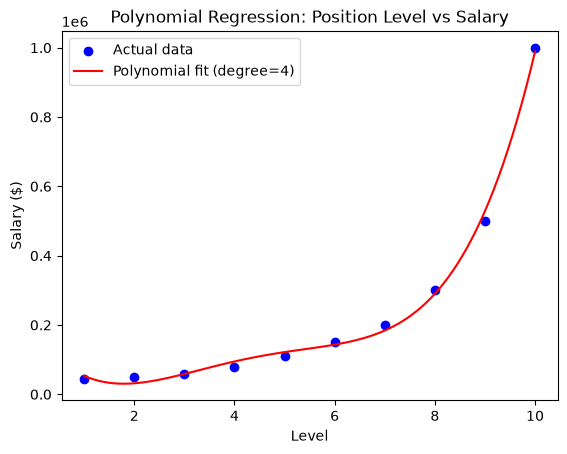

In [ ]:
X_range = np.linspace(X["Level"].min(), X["Level"].max(), 100).reshape(-1, 1)
y_curve = model.predict(poly.transform(X_range))

plt.scatter(X, Y, color="blue", label="Actual data")
plt.plot(X_range, y_curve, color="red", label="Polynomial fit (degree=4)")

plt.title("Polynomial Regression: Position Level vs Salary")
plt.xlabel("Level")
plt.ylabel("Salary ($)")
plt.legend()

plt.savefig("../visuals/poly_reg_salary.png")
plt.show()

Now solving for **5 unknowns** (β0 through β4), since `degree=4` creates the feature set `[1, x, x², x³, x⁴]`.

**Step 1 - the transformed feature table**

| Level (x) | x² | x³ | x⁴ | Salary (y) |
|---|---|---|---|---|
| 1 | 1 | 1 | 1 | 45,000 |
| 2 | 4 | 8 | 16 | 50,000 |
| 3 | 9 | 27 | 81 | 60,000 |
| 4 | 16 | 64 | 256 | 80,000 |
| 5 | 25 | 125 | 625 | 110,000 |
| 6 | 36 | 216 | 1296 | 150,000 |
| 7 | 49 | 343 | 2401 | 200,000 |
| 8 | 64 | 512 | 4096 | 300,000 |
| 9 | 81 | 729 | 6561 | 500,000 |
| 10 | 100 | 1000 | 10000 | 1,000,000 |

**Step 2 - the model now fits:**
$$y = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3 + \beta_4x^4$$

**Step 3 - this requires 5 simultaneous "normal equations,"** each built from different sums across all 10 rows (Σx, Σx², ... up to Σx⁸, plus Σy, Σxy, Σx²y, Σx³y, Σx⁴y). By hand, this becomes a **5×5 system** - genuinely impractical to solve with pen and paper (this is exactly why sklearn exists - it solves this using matrix algebra internally in a fraction of a second).

**Step 4 - the matrix shortcut (what sklearn actually does internally):**
Instead of writing out 5 equations one by one, it's expressed compactly as matrix multiplication:
$$\beta = (X^TX)^{-1}X^Ty$$
Where `X` is the entire 10×5 table above (including the constant `1` column), `Xᵀ` is its transpose, and `(XᵀX)⁻¹` is a matrix inverse. This one formula solves all 5 unknowns simultaneously - it's the generalized version of the mean/deviation formula from Linear Regression, extended to any number of coefficients.

**Step 5 - the resulting coefficients (approximately, matching your output):**
$$\beta_0 \approx 184{,}167 \quad \beta_1 \approx -211{,}002 \quad \beta_2 \approx 94{,}765 \quad \beta_3 \approx -15{,}463 \quad \beta_4 \approx 890$$

**Step 6 - the fitted curve:**
$$y \approx 184{,}167 - 211{,}002x + 94{,}765x^2 - 15{,}463x^3 + 890x^4$$

Notice the coefficients alternate sign and grow/shrink dramatically - that's a visible symptom of the overfitting risk mentioned earlier: the model is bending aggressively to pass close to every single point, using large positive and negative terms that partially cancel out at each x value.

**The honest core takeaway:** the math principle never changes from Linear Regression - still "minimize squared error between predictions and actual values" - but going from 2 unknowns → 3 unknowns → 5 unknowns turns a simple formula into a full matrix equation, which is exactly why real ML work relies on libraries like sklearn instead of hand-solved algebra past the simplest cases.